# Exploring the Werewolf Game Arena

Google DeepMind's [Werewolf Game Arena](https://www.kaggle.com/game-arena) dataset explores how large language models reason, deceive, and collaborate in social settings. In this setup, eight frontier LLMs play Werewolf, a social deduction game where hidden Werewolves must lie, accuse, and deceive to survive, while Villagers (including special roles such as the Doctor and the Seer) work together to identify and vote them out through discussion.

The dataset includes over 31,000 fully logged games, capturing every message, vote, accusation, and elimination. It offers a rare and detailed look at how AI models interact in a game of strategy, communication, and trust.

This notebook provides an initial exploration of the Werewolf Game Arena and is meant as a starting point for anyone interested in studying social reasoning, deception, and interaction among language models. For context and background, see the official [blog post](https://www.kaggle.com/blog/game-arena-werewolf).


---


## Models in the Game Arena
| Provider | Models |
|----------|--------|
| Anthropic | Claude Opus 4.5, Claude Sonnet 4.5 |
| Google | Gemini 3 Pro Preview, Gemini 3 Flash Preview |
| OpenAI | GPT-5.2, GPT-5 mini |
| xAI | Grok 4, Grok 4.1 Fast Reasoning |

## 1. Setup & Data Loading

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint


# environment
DATA_DIR = Path("/kaggle/input/datasets/organizations/kaggle/werewolf-dataset/werewolf_gzip_json_31479")
for subdir in sorted(DATA_DIR.iterdir()):
    if subdir.is_dir() and any(subdir.glob("*.json")):
        DATA_DIR = subdir
        break
OUTPUT_DIR = Path("/kaggle/working")
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)



# styling (relevant for plots)
MODEL_COLORS = {
    "Claude Opus 4.5": "#C4956A",
    "Claude Sonnet 4.5": "#D9B899",
    "Gemini 3 Pro Preview": "#4285F4",
    "Gemini 3 Flash Preview": "#78A9F5",
    "GPT-5.2": "#10A37F",
    "GPT-5 mini": "#6BCFB4",
    "Grok 4": "#E23A2F",
    "Grok 4.1 Fast Reasoning": "#F07B6E",
}

ROLE_COLORS = {
    "Werewolf": "#B8835F",
    "Villager": "#7FA3C1",
    "Seer": "#A07FD4",
    "Doctor": "#4DB6AC",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.color": "#000000",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

### Game Parser

Each game is a JSON file with structured event logs. The parser below extracts players, roles, events, outcomes, and elimination info into a dict.

In [2]:
def parse_game_file(filepath):
    """Parse a Kaggle Werewolf JSON into a lightweight dict."""
    with open(filepath, "r", encoding="utf-8") as f:
        raw = json.load(f)

    info = raw.get("info", {})
    config = raw.get("configuration", {})

    # Ground truth roles
    actual_roles = info.get("GAME_END", {}).get("all_players_and_role", {})

    players = []
    for agent in config.get("agents", []):
        pid = agent.get("id", "")
        players.append({
            "id": pid,
            "role": actual_roles.get(pid, agent.get("role", "Villager")),
            "model_name": (
                agent.get("display_name", "") or agent.get("agent_id", "")
            ),
        })

    werewolf_ids = {p["id"] for p in players if p["role"] == "Werewolf"}
    all_player_ids = {p["id"] for p in players}

    # Parse events
    events = []
    for step_events in info.get("MODERATOR_OBSERVATION", []):
        if not isinstance(step_events, list):
            continue
        for entry in step_events:
            if not isinstance(entry, dict):
                continue
            json_str = entry.get("json_str", "")
            if not json_str:
                continue
            try:
                ed = json.loads(json_str)
            except json.JSONDecodeError:
                continue
            if not isinstance(ed, dict):
                continue

            data = ed.get("data") or {}
            if not isinstance(data, dict):
                data = {}

            actor_id = data.get("actor_id", "")
            source = ed.get("source", "")
            if not actor_id and source and source != "MODERATOR":
                actor_id = source

            events.append({
                "event_name": ed.get("event_name", "unknown"),
                "day": ed.get("day", 0),
                "phase": ed.get("phase", ""),
                "actor_id": actor_id,
                "target_id": data.get("target_id", ""),
                "message": data.get("message", ""),
            })

    # Parse game outcome
    ge = info.get("GAME_END", {})
    winner = ge.get("winner_team", "")
    error = ge.get("terminated_with_agent_error", False)

    if error:
        outcome = "error"
    elif "werewol" in winner.lower():
        outcome = "werewolf_win"
    elif "village" in winner.lower():
        outcome = "village_win"
    else:
        outcome = "unknown"

    num_rounds = ge.get("last_day", 0) + 1
    if num_rounds <= 1 and events:
        num_rounds = max((e["day"] for e in events), default=0) + 1

    return {
        "game_id": Path(filepath).stem,
        "players": players,
        "events": events,
        "outcome": outcome,
        "num_rounds": num_rounds,
        "werewolf_ids": werewolf_ids,
        "all_player_ids": all_player_ids,
        "winner_ids": set(ge.get("winner_ids", [])),
        "elimination_info": ge.get("elimination_info", []),
    }


def load_all_games(data_dir):
    """Load every JSON game file from a directory."""
    files = sorted(
        f for f in Path(data_dir).glob("*.json")
        if not f.name.startswith("_")
    )
    games, errors = [], 0
    print("Starting ...")
    for i, fp in enumerate(files):
        if (i + 1) % 5000 == 0:
            print(f"  … loaded {i + 1:,}/{len(files):,}")
        try:
            games.append(parse_game_file(fp))
        except Exception:
            errors += 1
    print(f"Loaded {len(games):,} games  ({errors} errors)")
    return games


games = load_all_games(DATA_DIR)

Starting ...
  … loaded 5,000/31,479
  … loaded 10,000/31,479
  … loaded 15,000/31,479
  … loaded 20,000/31,479
  … loaded 25,000/31,479
  … loaded 30,000/31,479
Loaded 31,479 games  (0 errors)


## 2. Dataset Overview

In [3]:
# Helper functions for statistics
def wilson_ci(successes, total):
    """Wilson score 95% CI for a proportion. Returns (point, lo, hi)."""
    if total == 0:
        return 0.0, 0.0, 0.0
    lo, hi = proportion_confint(successes, total, alpha=0.05, method="wilson")
    return successes / total, lo, hi

def add_ci_columns(df):
    """Add ci_lo / ci_hi columns to a DataFrame with 'wins' and 'games' cols."""
    df[["ci_lo", "ci_hi"]] = df.apply(
        lambda r: pd.Series(wilson_ci(int(r["wins"]), int(r["games"]))[1:]),
        axis=1,
    )
    return df

In [4]:
# Game level
game_rows = []
for g in games:
    game_rows.append({
        "game_id": g["game_id"],
        "outcome": g["outcome"],
        "num_rounds": g["num_rounds"],
        "n_players": len(g["players"]),
    })
games_df = pd.DataFrame(game_rows)

# Player level
player_rows = []
for g in games:
    for p in g["players"]:
        model = p["model_name"]
        if not model or model == "random":
            continue
        is_ww = p["id"] in g["werewolf_ids"]
        won = p["id"] in g["winner_ids"]
        player_rows.append({
            "game_id": g["game_id"],
            "player_id": p["id"],
            "model": model,
            "role": p["role"],
            "is_werewolf": is_ww,
            "won": won,
            "outcome": g["outcome"],
            "num_rounds": g["num_rounds"],
        })

players_df = pd.DataFrame(player_rows)

# Message level
msg_data = []
for g in games:
    id_to_role = {p["id"]: p["role"] for p in g["players"]}
    id_to_model = {p["id"]: p["model_name"] for p in g["players"]}
    for e in g["events"]:
        msg = e.get("message", "")
        if not msg:
            continue
        actor = e["actor_id"]
        if actor not in id_to_role:
            continue
        msg_data.append({
            "role": id_to_role[actor],
            "model": id_to_model[actor],
            "word_count": len(msg.split()),
            "game_id": g["game_id"],
        })

msg_df = pd.DataFrame(msg_data)

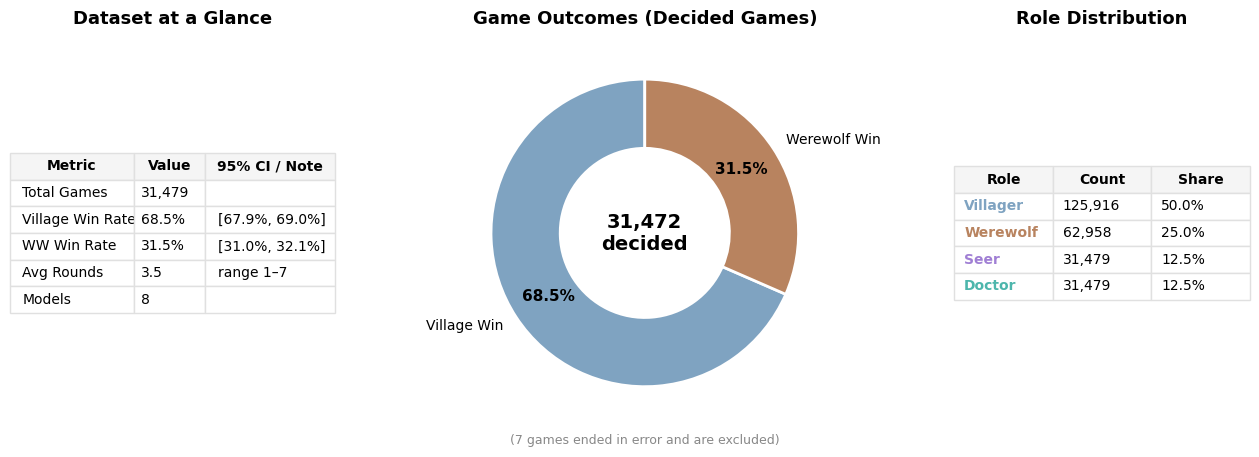

In [ ]:
outcome_counts = games_df["outcome"].value_counts()
decided = outcome_counts.get("village_win", 0) + outcome_counts.get("werewolf_win", 0)
vw, vw_lo, vw_hi = wilson_ci(outcome_counts.get("village_win", 0), decided)
ww, ww_lo, ww_hi = wilson_ci(outcome_counts.get("werewolf_win", 0), decided)

fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.3, 1.0], wspace=0.35)

# Stats table
ax_stats = fig.add_subplot(gs[0])
ax_stats.axis("off")

stats_rows = [
    ["Total Games", f"{len(games_df):,}", ""],
    ["Village Win Rate", f"{vw:.1%}", f"[{vw_lo:.1%}, {vw_hi:.1%}]"],
    ["WW Win Rate", f"{ww:.1%}", f"[{ww_lo:.1%}, {ww_hi:.1%}]"],
    ["Avg Rounds", f"{games_df['num_rounds'].mean():.1f}",
     f"range {games_df['num_rounds'].min()}\u2013{games_df['num_rounds'].max()}"],
    ["Models", f"{players_df['model'].nunique()}", ""],
]
table1 = ax_stats.table(
    cellText=stats_rows,
    colLabels=["Metric", "Value", "95% CI / Note"],
    colWidths=[0.38, 0.22, 0.40],
    loc="center", cellLoc="left",
)
table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1.0, 1.6)
for (row, col), cell in table1.get_celld().items():
    cell.set_edgecolor("#E0E0E0")
    if row == 0:
        cell.set_facecolor("#F5F5F5")
        cell.set_text_props(fontweight="bold")
    else:
        cell.set_facecolor("white")
ax_stats.set_title("Dataset at a Glance", fontsize=13, fontweight="bold", pad=12)


# Donut chart (decided games only, so percentages match the stats table)
ax_donut = fig.add_subplot(gs[1])
outcome_labels = []
outcome_sizes = []
outcome_colors = []
for display_label, outcome_key, color in [
    ("Village Win", "village_win", ROLE_COLORS["Villager"]),
    ("Werewolf Win", "werewolf_win", ROLE_COLORS["Werewolf"]),
]:
    count = outcome_counts.get(outcome_key, 0)
    if count > 0:
        outcome_labels.append(display_label)
        outcome_sizes.append(count)
        outcome_colors.append(color)

wedges, texts, autotexts = ax_donut.pie(
    outcome_sizes, labels=outcome_labels, colors=outcome_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    startangle=90, pctdistance=0.75,
    wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax_donut.text(0, 0, f"{decided:,}\ndecided", ha="center", va="center", fontsize=14, fontweight="bold")

err_count = len(games_df) - decided
if err_count > 0:
    ax_donut.text(0, -1.35, f"({err_count:,} games ended in error and are excluded)",
                  ha="center", va="center", fontsize=9, color="#888")

ax_donut.set_title("Game Outcomes (Decided Games)", fontsize=13, fontweight="bold", pad=12)


# Role distribution table
ax_roles = fig.add_subplot(gs[2])
ax_roles.axis("off")

role_order_summary = ["Villager", "Werewolf", "Seer", "Doctor"]
role_rows = []
for role in role_order_summary:
    cnt = (players_df["role"] == role).sum()
    role_rows.append([role, f"{cnt:,}", f"{cnt / len(players_df):.1%}"])

table2 = ax_roles.table(
    cellText=role_rows,
    colLabels=["Role", "Count", "Share"],
    loc="center", cellLoc="left",
)
table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1.0, 1.6)
for (row, col), cell in table2.get_celld().items():
    cell.set_edgecolor("#E0E0E0")
    if row == 0:
        cell.set_facecolor("#F5F5F5")
        cell.set_text_props(fontweight="bold")
    elif row > 0:
        cell.set_facecolor("white")
        if col == 0:
            role_name = role_order_summary[row - 1]
            cell.set_text_props(color=ROLE_COLORS[role_name], fontweight="bold")

ax_roles.set_title("Role Distribution", fontsize=13, fontweight="bold", pad=12)

plt.savefig(PLOT_DIR / "dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("games_df:")
print(games_df.head())
print("\nplayers_df:")
print(players_df.head())

## 3. Game Dynamics

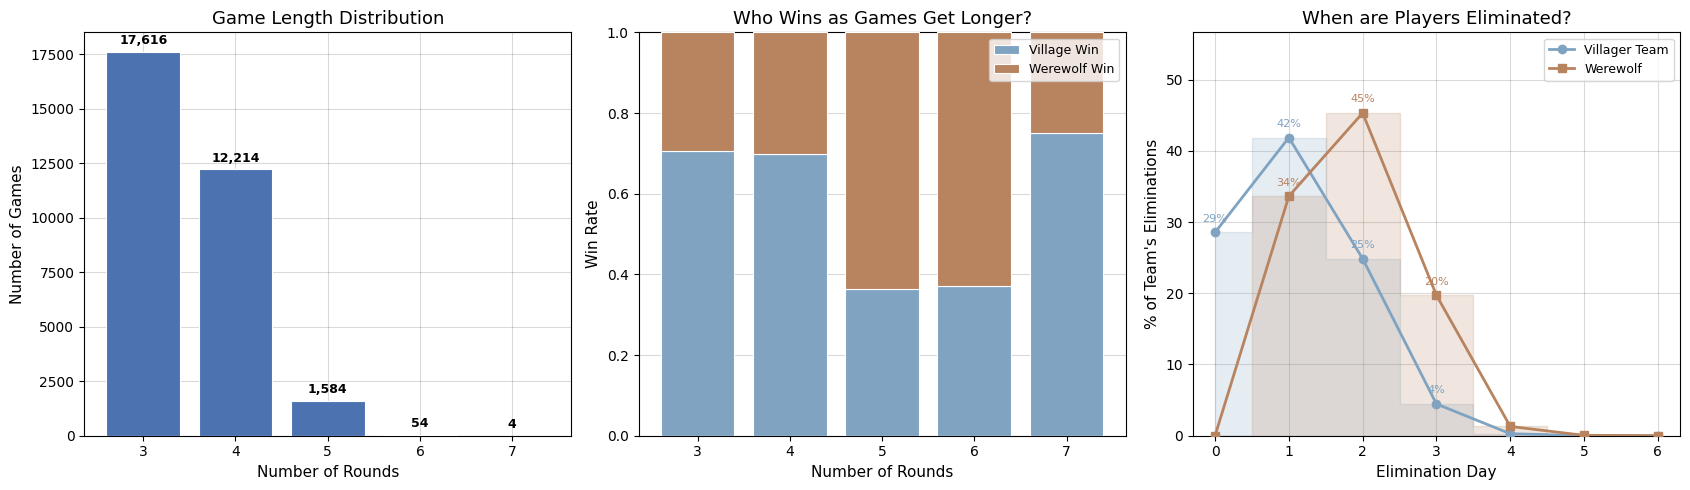

In [ ]:
decided_df = games_df[games_df["outcome"].isin(["village_win", "werewolf_win"])]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Game length distribution
ax = axes[0]
round_counts = decided_df["num_rounds"].value_counts().sort_index()
ax.bar(
    round_counts.index, round_counts.values,
    color="#4C72B0", edgecolor="white", linewidth=0.8, zorder=3,
)
for r, c in round_counts.items():
    ax.text(r, c + round_counts.max() * 0.02, f"{c:,}",
                ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Number of Rounds")
ax.set_ylabel("Number of Games")
ax.set_title("Game Length Distribution")

# Win rate by game length
ax = axes[1]
length_wr = (
    decided_df.groupby("num_rounds")["outcome"]
    .apply(lambda x: (x == "village_win").mean())
    .reset_index(name="village_wr")
)
ax.bar(
    length_wr["num_rounds"], length_wr["village_wr"],
    color=ROLE_COLORS["Villager"], edgecolor="white", linewidth=0.8,
    label="Village Win", zorder=3,
)
ax.bar(
    length_wr["num_rounds"], 1 - length_wr["village_wr"],
    bottom=length_wr["village_wr"],
    color=ROLE_COLORS["Werewolf"], edgecolor="white", linewidth=0.8,
    label="Werewolf Win", zorder=3,
)
ax.set_xlabel("Number of Rounds")
ax.set_ylabel("Win Rate")
ax.set_title("Who Wins as Games Get Longer?")
ax.legend(fontsize=9, loc="upper right")
ax.set_ylim(0, 1)

# Elimination timing by team
ww_elim, vill_elim = [], []
for g in games:
    for ei in g["elimination_info"]:
        if not isinstance(ei, dict):
            continue
        day = ei.get("eliminated_during_day", -1)
        if day < 0:
            continue
        pid = ei.get("player_id", "")
        if pid in g["werewolf_ids"]:
            ww_elim.append(day)
        else:
            vill_elim.append(day)

ax = axes[2]
max_day = max(max(ww_elim, default=0), max(vill_elim, default=0))
days = np.arange(0, max_day + 1)
vill_counts = np.array([(np.array(vill_elim) == d).sum() for d in days])
ww_counts = np.array([(np.array(ww_elim) == d).sum() for d in days])
vill_pct = vill_counts / vill_counts.sum() * 100
ww_pct = ww_counts / ww_counts.sum() * 100

ax.fill_between(days, vill_pct, alpha=0.2, color=ROLE_COLORS["Villager"],
                step="mid", zorder=2)
ax.fill_between(days, ww_pct, alpha=0.2, color=ROLE_COLORS["Werewolf"],
                step="mid", zorder=2)
ax.plot(days, vill_pct, "o-", color=ROLE_COLORS["Villager"], linewidth=2,
        markersize=6, label="Villager Team", zorder=3)
ax.plot(days, ww_pct, "s-", color=ROLE_COLORS["Werewolf"], linewidth=2,
        markersize=6, label="Werewolf", zorder=3)
for d, vp, wp in zip(days, vill_pct, ww_pct):
    if vp > 2:
        ax.text(d, vp + 1.5, f"{vp:.0f}%", ha="center", fontsize=8,
                color=ROLE_COLORS["Villager"])
    if wp > 2:
        ax.text(d, wp + 1.5, f"{wp:.0f}%", ha="center", fontsize=8,
                color=ROLE_COLORS["Werewolf"])
ax.set_xlabel("Elimination Day")
ax.set_ylabel("% of Team's Eliminations")
ax.set_title("When are Players Eliminated?")
ax.legend(fontsize=9)
ax.set_xticks(days)
ax.set_ylim(0, max(vill_pct.max(), ww_pct.max()) * 1.25)

plt.tight_layout()
plt.savefig(PLOT_DIR / "game_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Model Performance

In [7]:
# Only count decided games (exclude errors/unknowns)
decided_players = players_df[
    players_df["outcome"].isin(["village_win", "werewolf_win"])
].copy()

# Computing win rates per model across roles
wr_data = (
    decided_players.groupby(["model", "role"])
    .agg(wins=("won", "sum"), games=("won", "count"))
    .reset_index()
)
wr_data["win_rate"] = wr_data["wins"] / wr_data["games"]
add_ci_columns(wr_data)

# Shared display helpers (used in all subsequent plots)
models_sorted = sorted(wr_data["model"].unique())
short_names = {
    m: m.replace(" Preview", "").replace(" Reasoning", "")
    for m in models_sorted
}

roles_order = ["Werewolf", "Villager", "Seer", "Doctor"]

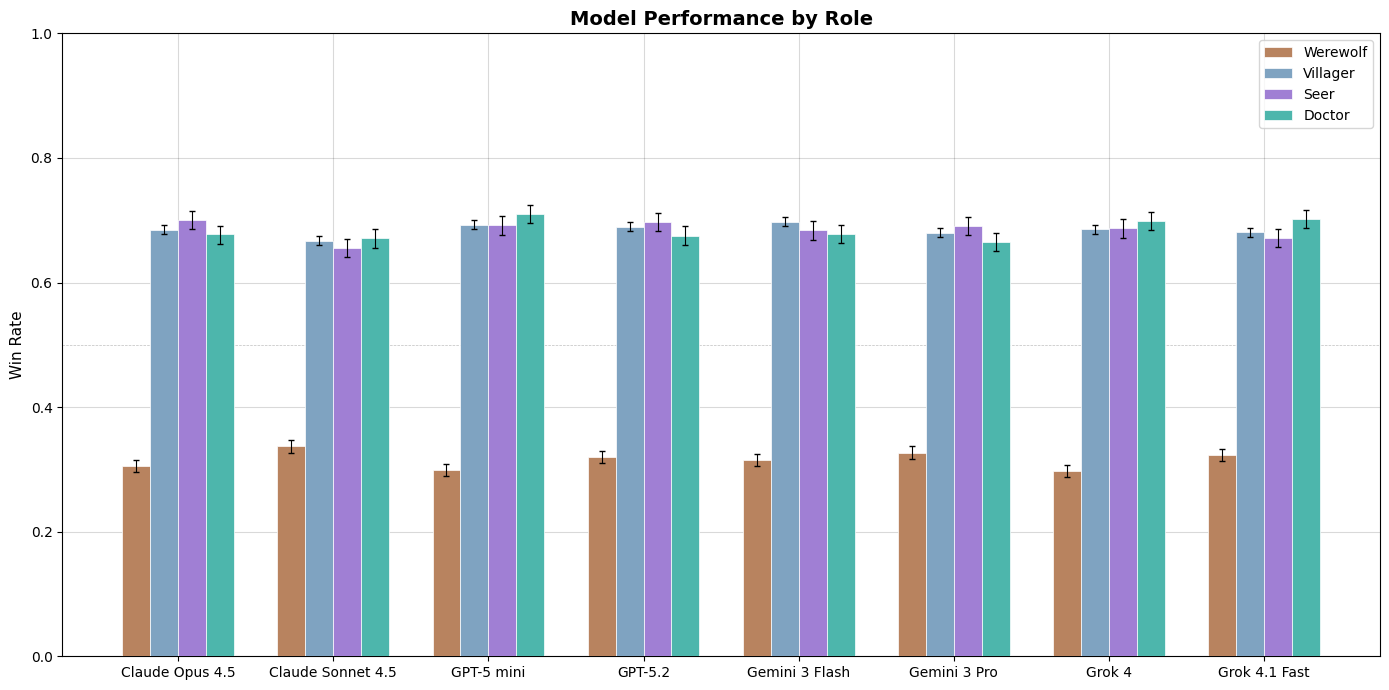

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

n_models = len(models_sorted)
n_roles = len(roles_order)
bar_width = 0.18
x = np.arange(n_models)

for i, role in enumerate(roles_order):
    role_wr = []
    role_ci_lo = []
    role_ci_hi = []
    for model in models_sorted:
        row = wr_data[(wr_data["model"] == model) & (wr_data["role"] == role)]
        if row.empty:
            role_wr.append(0)
            role_ci_lo.append(0)
            role_ci_hi.append(0)
        else:
            r = row.iloc[0]
            role_wr.append(r["win_rate"])
            role_ci_lo.append(r["win_rate"] - r["ci_lo"])
            role_ci_hi.append(r["ci_hi"] - r["win_rate"])

    offset = (i - n_roles / 2 + 0.5) * bar_width
    bars = ax.bar(
        x + offset, role_wr, bar_width,
        yerr=[role_ci_lo, role_ci_hi],
        capsize=2, error_kw={"linewidth": 0.8},
        label=role, color=ROLE_COLORS[role],
        edgecolor="white", linewidth=0.5, zorder=3,
    )

ax.set_xticks(x)
ax.set_xticklabels([short_names[m] for m in models_sorted], fontsize=10)
ax.set_ylabel("Win Rate")
ax.set_title("Model Performance by Role", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="upper right")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(PLOT_DIR / "win_rate_by_role.png", dpi=150, bbox_inches="tight")
plt.show()

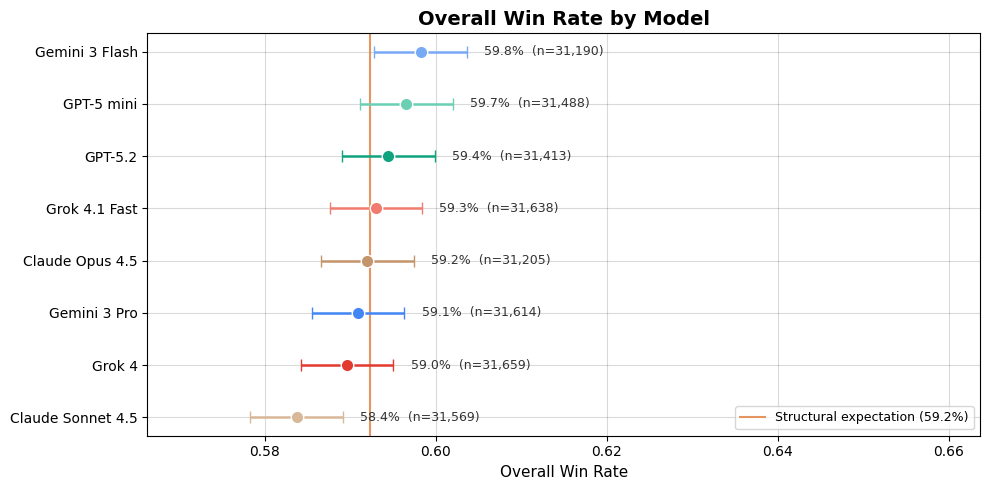

In [9]:
overall_wr = (
    decided_players.groupby("model")
    .agg(wins=("won", "sum"), games=("won", "count"))
    .reset_index()
)
overall_wr["win_rate"] = overall_wr["wins"] / overall_wr["games"]
overall_wr = overall_wr.sort_values("win_rate", ascending=True).reset_index(drop=True)

add_ci_columns(overall_wr)

# Structural baseline: expected win rate from role distribution alone. P(win) = P(village role) * P(village wins) + P(ww role) * P(ww wins)
structural_baseline = 0.75 * vw + 0.25 * ww

fig, ax = plt.subplots(figsize=(10, 5))
short = [short_names.get(m, m) for m in overall_wr["model"]]
y_pos = np.arange(len(overall_wr))

# Structural baseline band
ax.axvline(structural_baseline, color="#E07B39", linewidth=1.5, linestyle="-",
           alpha=0.8, zorder=2, label=f"Structural expectation ({structural_baseline:.1%})")

# Dot + CI for each model
for i, (_, row) in enumerate(overall_wr.iterrows()):
    color = MODEL_COLORS.get(row["model"], "#999")
    ax.errorbar(
        row["win_rate"], i,
        xerr=[[row["win_rate"] - row["ci_lo"]], [row["ci_hi"] - row["win_rate"]]],
        fmt="o", color=color, markersize=9, capsize=4, linewidth=1.8,
        markeredgecolor="white", markeredgewidth=1.0, zorder=4,
    )
    ax.text(row["ci_hi"] + 0.002, i, f"{row['win_rate']:.1%}  (n={int(row['games']):,})",
            va="center", fontsize=9, color="#333")

# Focus axis on the data range
x_pad = 0.012
ax.set_xlim(overall_wr["ci_lo"].min() - x_pad, overall_wr["ci_hi"].max() + 0.06)
ax.set_yticks(y_pos)
ax.set_yticklabels(short, fontsize=10)
ax.set_xlabel("Overall Win Rate")
ax.set_title("Overall Win Rate by Model", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(PLOT_DIR / "overall_win_rate.png", dpi=150, bbox_inches="tight")
plt.show()

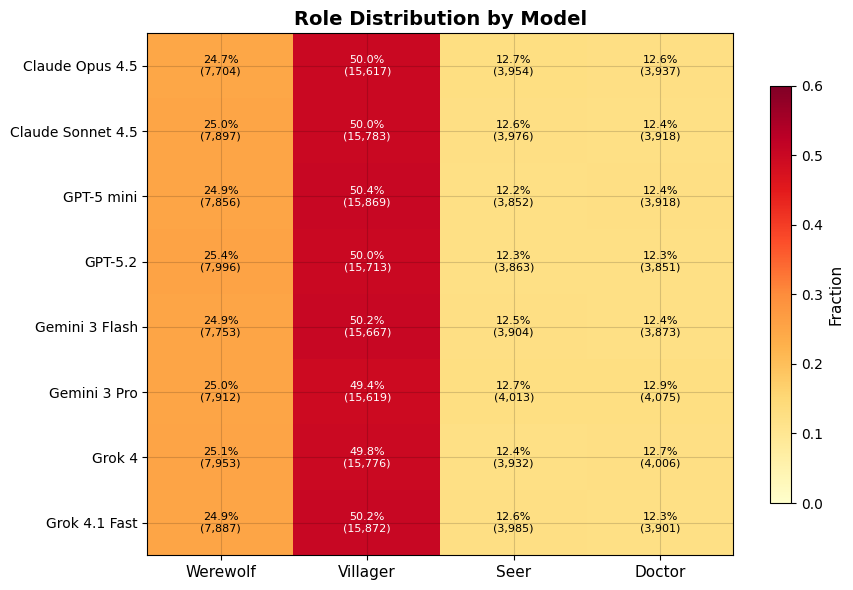

In [10]:
role_dist = (
    players_df.groupby(["model", "role"]).size()
    .unstack(fill_value=0)
)
# Normalizing per model
role_pct = role_dist.div(role_dist.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 6))
display = role_pct[roles_order].reindex(models_sorted)

im = ax.imshow(display.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=0.6)
ax.set_xticks(range(len(roles_order)))
ax.set_xticklabels(roles_order, fontsize=11)
ax.set_yticks(range(len(models_sorted)))
ax.set_yticklabels([short_names[m] for m in models_sorted], fontsize=10)

# Annotating cells
for i in range(len(models_sorted)):
    for j in range(len(roles_order)):
        val = display.values[i, j]
        count = role_dist.loc[models_sorted[i], roles_order[j]]
        color = "white" if val > 0.35 else "black"
        ax.text(j, i, f"{val:.1%}\n({count:,})", ha="center", va="center",
                fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label="Fraction")
ax.set_title("Role Distribution by Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "role_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Behavioral Patterns

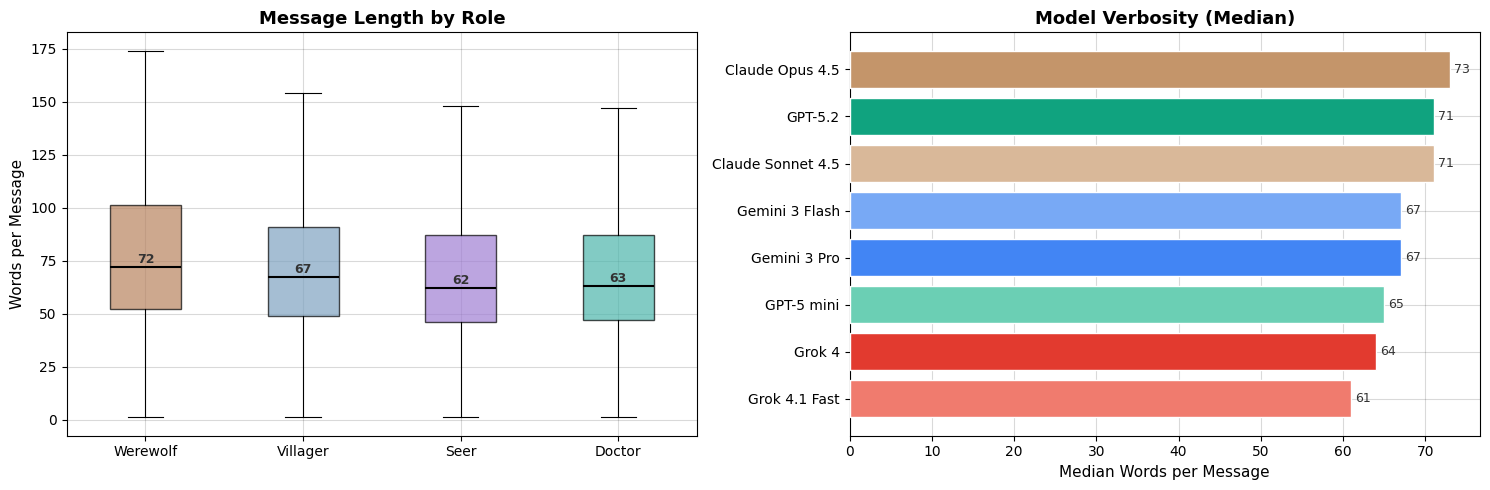

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Message length distribution by role
ax = axes[0]
bp_data = [msg_df[msg_df["role"] == r]["word_count"].values for r in roles_order]
bp = ax.boxplot(
    bp_data, tick_labels=roles_order, patch_artist=True, showfliers=False,
    medianprops={"color": "black", "linewidth": 1.5},
    whiskerprops={"linewidth": 0.8},
    capprops={"linewidth": 0.8},
)
for patch, role in zip(bp["boxes"], roles_order):
    patch.set_facecolor(ROLE_COLORS[role])
    patch.set_alpha(0.7)

# Annotating medians
for i, role in enumerate(roles_order):
    median_val = msg_df[msg_df["role"] == role]["word_count"].median()
    ax.text(i + 1, median_val + 2, f"{median_val:.0f}",
            ha="center", fontsize=9, fontweight="bold", color="#333")

ax.set_ylabel("Words per Message")
ax.set_title("Message Length by Role", fontsize=13, fontweight="bold")


# Median message length per model
ax = axes[1]
model_med = msg_df.groupby("model")["word_count"].median().sort_values()
colors = [MODEL_COLORS.get(m, "#999") for m in model_med.index]
short_labels = [short_names.get(m, m) for m in model_med.index]

ax.barh(range(len(model_med)), model_med.values, color=colors,
        edgecolor="white", zorder=3)
for i, v in enumerate(model_med.values):
    ax.text(v + 0.5, i, f"{v:.0f}", va="center", fontsize=9, color="#333")
ax.set_yticks(range(len(model_med)))
ax.set_yticklabels(short_labels, fontsize=10)
ax.set_xlabel("Median Words per Message")
ax.set_title("Model Verbosity (Median)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(PLOT_DIR / "behavioral_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Findings

- **31,479 games** across 8 frontier LLMs (Anthropic, Google, OpenAI, xAI). Games ending in agent errors are excluded from all win-rate analyses. Therefore, only completed games (those resulting in either a village or werewolf win) are included. Roles are assigned uniformly at random, with no detectable model bias.
- **Villagers win ~68.5%** of decided games [95% CI: 67.9%–69.0%]. The game designers note ~60% village win rate when a single model plays all roles. The higher rate with mixed models suggests that model heterogeneity amplifies the structural village advantage.
- **Most games end in 3 rounds** ( ~56%), followed by 4 rounds ( ~39%). Shorter games strongly favor Villagers ( ~70% at 3 rounds). Longer games shift toward Werewolves ( ~60%+ at 5+ rounds).
- **Raw model win rates cluster tightly** ( ~58–60% overall). With ~75% village-aligned role assignments and a ~68.5% village win rate, the expected overall win rate is ~59.3% for any model regardless of skill. Per-role variation is narrow.
- **Communication patterns vary more across models than across roles.** Message length distributions are similar for Werewolves and Villagers. Model-level verbosity differences are more pronounced.
- The official [Werewolf Leaderboard](https://www.kaggle.com/benchmarks/kaggle/werewolf) uses the *polarix* library to compute skill ratings via a meta-game equilibrium approach that controls for opponent composition, role-specific skills, and non-transitive dynamics - factors that raw win rates cannot capture. Rankings here should not be compared directly to that leaderboard.

---


**References**
- [Kaggle Game Arena](https://www.kaggle.com/game-arena)
- [Kaggle Game Arena Blog](https://www.kaggle.com/blog/game-arena-werewolf)
- [DeepMind Game Arena Blog](https://blog.google/innovation-and-ai/models-and-research/google-deepmind/kaggle-game-arena-updates/)
- [Werewolf Leaderboard](https://www.kaggle.com/benchmarks/kaggle/werewolf)

In [ ]:
# Diagnostic: discover vote elimination structure
from collections import Counter
phase_counts = Counter()
non_night_samples = []
for g in games:
    for ei in g.get("elimination_info", []):
        if not isinstance(ei, dict):
            continue
        phase = ei.get("eliminated_during_phase")
        day = ei.get("eliminated_during_day")
        phase_counts[phase] += 1
        if phase and str(phase).lower() != "night" and day >= 0:
            non_night_samples.append((g["game_id"], day, phase, ei.get("player_id")))

print("eliminated_during_phase distribution:", dict(phase_counts.most_common()))
print("Non-Night eliminations (day>=0, first 15):", non_night_samples[:15])

# Check elimination events
elim_events = [e for g in games[:100] for e in g["events"] if (e.get("event_name") or "") == "elimination"]
print(f"\nElimination events (first 100 games): {len(elim_events)}")
if elim_events:
    print("Sample elimination event keys:", list(elim_events[0].keys()))

In [ ]:
# Extract game states for LLM reproduction: manipulation vs detection

def get_vote_events(events):
    """Extract village Day votes only (exclude werewolf Night votes)."""
    vote_events = []
    for e in events:
        en = (e.get("event_name") or "").lower()
        if "vote" in en and e.get("target_id"):
            phase = (e.get("phase") or "").lower()
            if phase == "night":
                continue  # Werewolf night vote, not village day vote
            vote_events.append(e)
    return vote_events


def _vote_day_matches_elim_day(vote_day, elim_day):
    """elimination_info uses 1-indexed days; vote_action may use 0-indexed."""
    return vote_day == elim_day or vote_day == elim_day - 1


def _is_vote_elimination(ei: dict) -> bool:
    """Exclude Night kills (werewolf attacks); only vote eliminations."""
    if not isinstance(ei, dict):
        return False
    phase = (ei.get("eliminated_during_phase") or "").lower()
    if phase == "night":
        return False
    if ei.get("eliminated_during_day", -1) < 0:
        return False
    return True


def extract_manipulation_wins(games):
    """
    Extract games where werewolf won by manipulating villagers to vote against other villagers.
    Returns list of dicts with full game state for LLM reproduction.
    """
    results = []
    for g in games:
        if g["outcome"] != "werewolf_win":
            continue

        werewolf_ids = g["werewolf_ids"]
        villager_ids = g["all_player_ids"] - werewolf_ids
        id_to_name = {p["id"]: p["model_name"] for p in g["players"]}

        vote_events = get_vote_events(g["events"])

        for ei in g.get("elimination_info", []):
            if not _is_vote_elimination(ei):
                continue
            eliminated_id = ei.get("player_id", "")
            elim_day = ei.get("eliminated_during_day", -1)

            if eliminated_id in werewolf_ids:
                continue

            day_votes = [
                v for v in vote_events
                if _vote_day_matches_elim_day(v.get("day", -1), elim_day)
                and v.get("target_id") == eliminated_id
            ]

            villager_votes_for_villager = [
                v for v in day_votes
                if v["actor_id"] in villager_ids and v["target_id"] in villager_ids
            ]

            if not villager_votes_for_villager:
                continue

            day_messages = [
                e for e in g["events"]
                if _vote_day_matches_elim_day(e.get("day", -1), elim_day)
                and e.get("message")
                and (e.get("event_name") or "").lower() not in ("vote", "voteevent", "vote_action")
            ]

            results.append({
                "game_id": g["game_id"],
                "scenario": "werewolf_manipulation_win",
                "n_players": len(g["players"]),
                "eliminated_villager_id": eliminated_id,
                "eliminated_villager_name": id_to_name.get(eliminated_id, ""),
                "day": elim_day,
                "villager_votes_against_villager": [
                    {"voter": id_to_name.get(v["actor_id"]), "target": id_to_name.get(v["target_id"])}
                    for v in villager_votes_for_villager
                ],
                "werewolf_ids": list(werewolf_ids),
                "players": g["players"],
                "events": g["events"],
                "discussion_before_vote": day_messages,
                "elimination_info": g["elimination_info"],
            })
            break

    return results


def extract_detection_wins(games):
    """
    Extract games where villagers detected werewolf(s) and won.
    Returns list of dicts with full game state for LLM reproduction.
    """
    results = []
    for g in games:
        if g["outcome"] != "village_win":
            continue

        werewolf_ids = g["werewolf_ids"]
        villager_ids = g["all_player_ids"] - werewolf_ids
        id_to_name = {p["id"]: p["model_name"] for p in g["players"]}

        vote_events = get_vote_events(g["events"])

        for ei in g.get("elimination_info", []):
            if not _is_vote_elimination(ei):
                continue
            eliminated_id = ei.get("player_id", "")
            elim_day = ei.get("eliminated_during_day", -1)

            if eliminated_id not in werewolf_ids:
                continue

            day_votes = [
                v for v in vote_events
                if _vote_day_matches_elim_day(v.get("day", -1), elim_day)
                and v.get("target_id") == eliminated_id
            ]
            villager_votes_for_werewolf = [
                v for v in day_votes if v["actor_id"] in villager_ids
            ]

            if not villager_votes_for_werewolf:
                continue

            day_messages = [
                e for e in g["events"]
                if _vote_day_matches_elim_day(e.get("day", -1), elim_day)
                and e.get("message")
                and (e.get("event_name") or "").lower() not in ("vote", "voteevent", "vote_action")
            ]

            ww_name = id_to_name.get(eliminated_id, "")

            results.append({
                "game_id": g["game_id"],
                "scenario": "villager_detection_win",
                "n_players": len(g["players"]),
                "eliminated_werewolf_id": eliminated_id,
                "eliminated_werewolf_name": ww_name,
                "day": elim_day,
                "villager_votes_for_werewolf": [
                    {"voter": id_to_name.get(v["actor_id"]), "target": ww_name}
                    for v in villager_votes_for_werewolf
                ],
                "werewolf_ids": list(werewolf_ids),
                "players": g["players"],
                "events": g["events"],
                "discussion_before_vote": day_messages,
                "elimination_info": g["elimination_info"],
            })
            break

    return results


def build_llm_prompt_state(extracted: dict, max_messages: int = 50) -> dict:
    """
    Build a compact game state for LLM few-shot or generation prompts.
    Use for: 'Reproduce a similar game with N players' or 'Continue this discussion'.
    """
    scenario = extracted["scenario"]
    players = extracted["players"]

    transcript = []
    for e in extracted.get("discussion_before_vote", extracted.get("events", [])):
        msg = e.get("message", "")
        if not msg:
            continue
        actor = e.get("actor_id", "")
        role = next((p["role"] for p in players if p["id"] == actor), "?")
        name = next((p["model_name"] for p in players if p["id"] == actor), actor)
        transcript.append({"role": role, "name": name, "message": msg})
        if len(transcript) >= max_messages:
            break

    return {
        "scenario": scenario,
        "n_players": len(players),
        "roles": [p["role"] for p in players],
        "transcript": transcript,
        "key_outcome": (
            f"Villager {extracted.get('eliminated_villager_name', '?')} was voted out (manipulated)"
            if scenario == "werewolf_manipulation_win"
            else f"Werewolf {extracted.get('eliminated_werewolf_name', '?')} was correctly identified and voted out"
        ),
        "game_id": extracted.get("game_id", ""),
    }


# Run extraction
manipulation_games = extract_manipulation_wins(games)
detection_games = extract_detection_wins(games)

print(f"Manipulation wins (werewolf tricks villager): {len(manipulation_games)}")
print(f"Detection wins (villager catches werewolf): {len(detection_games)}")

# Example: build LLM prompt states for reproduction with variety
for ex in manipulation_games[:3]:
    state = build_llm_prompt_state(ex)
    print(f"  {ex['game_id']}: {state['key_outcome']}")

for ex in detection_games[:3]:
    state = build_llm_prompt_state(ex)
    print(f"  {ex['game_id']}: {state['key_outcome']}")

## 7. Using extracted data for LLM reproduction

Use the seeds to generate synthetic games with variety (different player counts, discussion lengths).

In [ ]:
# Next steps: use extracted data for LLM reproduction

# 1. Save to JSONL for reuse (run after extraction)
import json
OUTPUT_DIR = Path("/kaggle/working")  # or Path(".") for local

for name, items in [("manipulation", manipulation_games), ("detection", detection_games)]:
    out_path = OUTPUT_DIR / f"werewolf_{name}_seeds.jsonl"
    with open(out_path, "w") as f:
        for ex in items:
            state = build_llm_prompt_state(ex)
            f.write(json.dumps(state, ensure_ascii=False) + "\n")
    print(f"Saved {len(items)} {name} seeds to {out_path}")

# 2. Example LLM prompt for reproduction (manipulation scenario)
def make_reproduction_prompt(seed: dict, n_players: int = 6) -> str:
    """Build a prompt asking LLM to generate a similar game with variety."""
    transcript = seed.get("transcript", [])
    lines = [f"{t['name']} ({t['role']}): {t['message']}" for t in transcript[:20]]
    return f"""Generate a Werewolf game transcript similar to this one, but with {n_players} players.

Scenario: {seed['key_outcome']}
Roles in original: {seed['roles']}

Example discussion:
{chr(10).join(lines)}

Produce a new discussion leading to the same type of outcome. Use different player names. Format each line as "Name (Role): message\""""

# 3. Sample prompts for few-shot or generation
sample_manip = build_llm_prompt_state(manipulation_games[0]) if manipulation_games else {}
sample_detect = build_llm_prompt_state(detection_games[0]) if detection_games else {}

if sample_manip:
    print("--- Manipulation prompt (6 players) ---")
    print(make_reproduction_prompt(sample_manip, 6)[:500] + "...")
if sample_detect:
    print("\n--- Detection prompt (6 players) ---")
    print(make_reproduction_prompt(sample_detect, 6)[:500] + "...")